In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.options.display.float_format = '{:20.2f}'.format
pd.set_option('display.max_columns', 999)
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_excel(r'/Users/mohamedtarek/Downloads/Customer Segmentation/online_retail_II.xlsx',sheet_name=0)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [5]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [6]:
df[df['Customer ID'].isnull()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
df[df['Quantity']< 0 ].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [8]:
df['Invoice'] = df['Invoice'].astype('str')
df[df['Invoice'].str.match(r"^\d{6}$") == False].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [9]:
df['Invoice'].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [10]:
df[df['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [11]:
df['StockCode'] = df['StockCode'].astype('str')
df[(df['StockCode'].str.match(r"^\d{5}$")== False) & (df['StockCode'].str.match(r"^\d{5}[a-zA-Z]+$")== False)]['StockCode'].unique()


array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [12]:
df[df['StockCode'].str.contains('^DOT')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


In [13]:
cleaned_df = df.copy()

In [14]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype('str')

mask = (
    cleaned_df['Invoice'].str.match(r"^\d{6}$") == True         
)

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [15]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')

mask = (
    (cleaned_df['StockCode'].str.match(r"^\d{5}$") == True)
    | (cleaned_df['StockCode'].str.match(r"^\d{5}[a-zA-Z]+$") == True)
    | (cleaned_df['StockCode'].str.contains('^PADS') == True)
)
cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [16]:
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

In [17]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543288320,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [18]:
len(cleaned_df[cleaned_df['Price'] == 0])

28

In [19]:
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

In [20]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.00,406309,406309.00,406309.00
mean,13.62,2010-07-01 10:14:25.869572352,2.99,15373.72
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14006.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.33


In [21]:
len(cleaned_df)/len(df)

0.7732429238325965

In [22]:
cleaned_df['total_sales'] = cleaned_df['Quantity'] * cleaned_df['Price']

In [23]:
aggregated_data = cleaned_df.groupby('Customer ID', as_index=False).agg(
    MonetaryValue = ("total_sales","sum"),
    Frequency = ("Invoice","nunique"),
    LastInvoiceDate = ("InvoiceDate","max")
)
aggregated_data.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00


In [24]:
max_invoice_date = aggregated_data['LastInvoiceDate'].max()

aggregated_data['Recency'] = (max_invoice_date - aggregated_data['LastInvoiceDate']).dt.days

aggregated_data.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


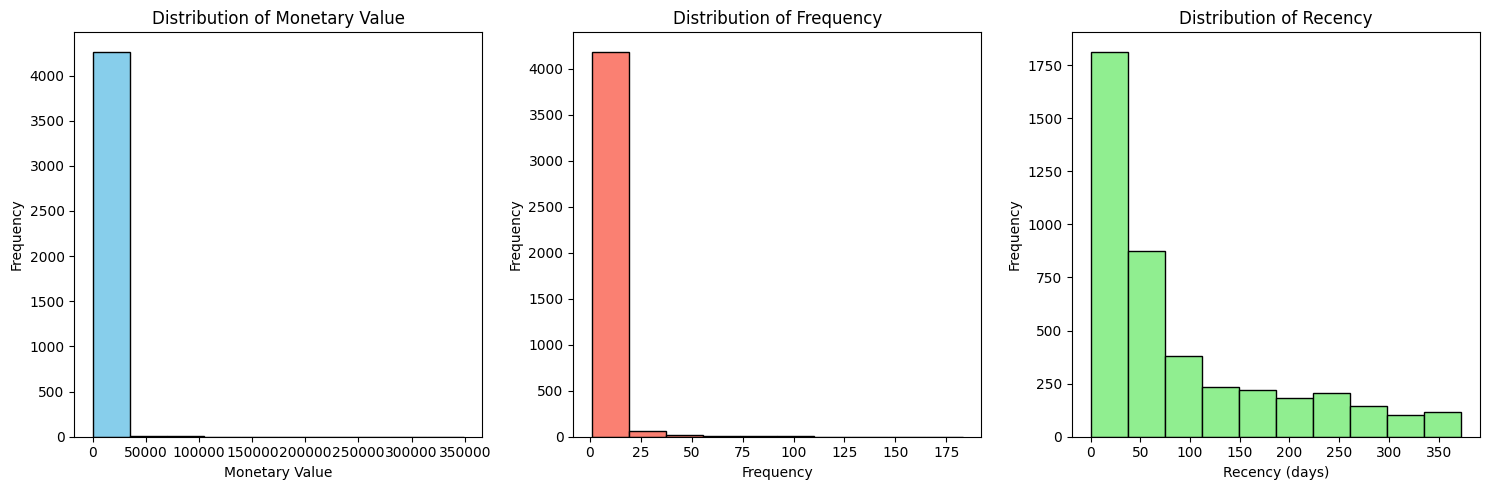

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_data['MonetaryValue'], bins=10,color='skyblue', edgecolor='black')
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(aggregated_data['Frequency'], bins=10,color='salmon', edgecolor='black')
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(aggregated_data['Recency'], bins=10,color='lightgreen', edgecolor='black')
plt.title('Distribution of Recency')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

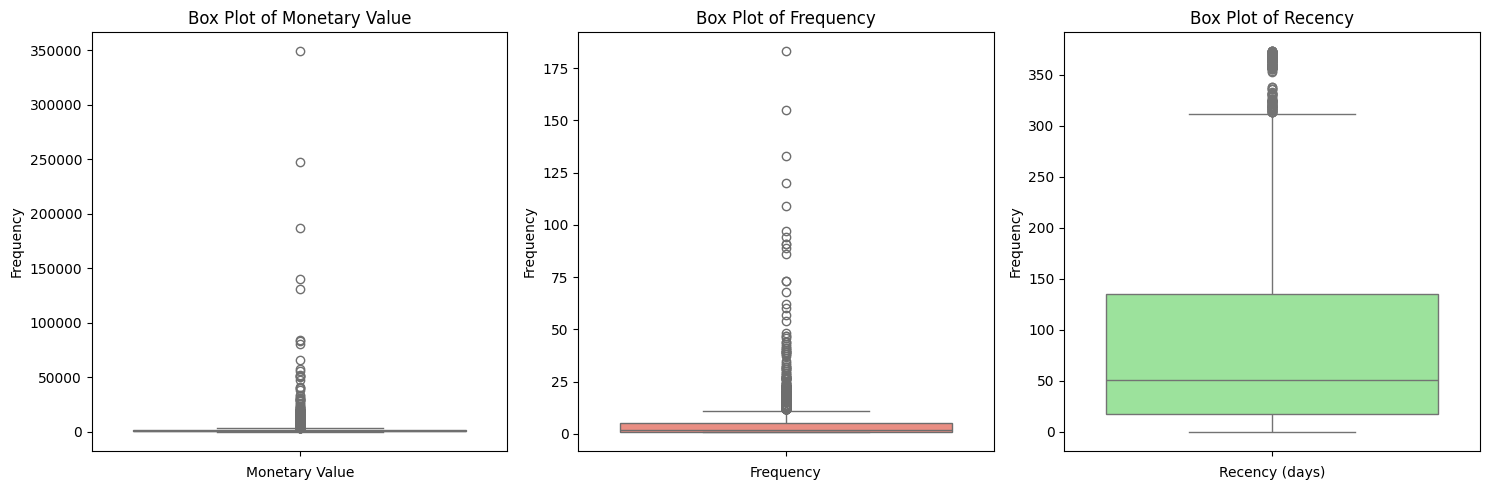

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=aggregated_data['MonetaryValue'], color='skyblue')
plt.title('Box Plot of Monetary Value')
plt.xlabel('Monetary Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.boxplot(y=aggregated_data['Frequency'], color='salmon')
plt.title('Box Plot of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(y=aggregated_data['Recency'], color='lightgreen')
plt.title('Box Plot of Recency')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [27]:
M_Q1 = aggregated_data['MonetaryValue'].quantile(0.25)
M_Q3 = aggregated_data['MonetaryValue'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

monetary_outliers_df = aggregated_data[
    (aggregated_data['MonetaryValue'] > (M_Q3 + 1.5 * M_IQR)) |
    (aggregated_data['MonetaryValue'] < (M_Q1 - 1.5 * M_IQR))
].copy()

monetary_outliers_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723328,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


In [28]:
M_Q1 = aggregated_data['Frequency'].quantile(0.25)
M_Q3 = aggregated_data['Frequency'].quantile(0.75)
M_IQR = M_Q3 - M_Q1

Frequency_outliers_df = aggregated_data[
    (aggregated_data['Frequency'] > (M_Q3 + 1.5 * M_IQR)) |
    (aggregated_data['Frequency'] < (M_Q1 - 1.5 * M_IQR))
].copy()

Frequency_outliers_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161216,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


In [29]:
non_outliers_df = aggregated_data[(~aggregated_data.index.isin(monetary_outliers_df.index)) & (~aggregated_data.index.isin(Frequency_outliers_df.index))]

non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


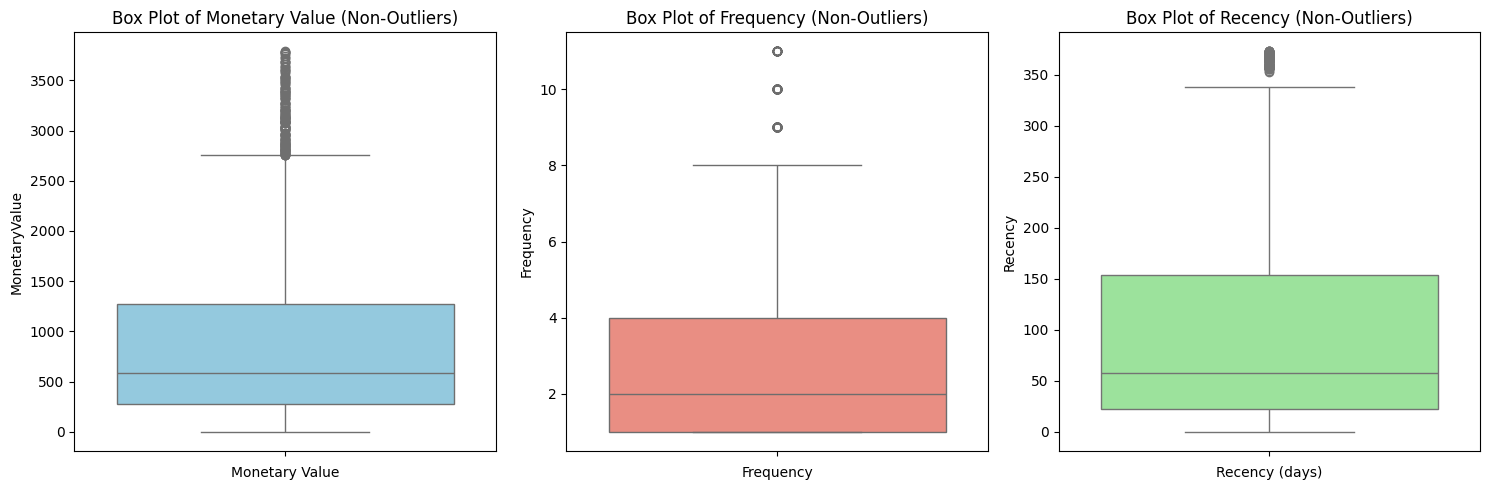

In [30]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Box Plot of Monetary Value (Non-Outliers)')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(y=non_outliers_df['Frequency'], color='salmon')
plt.title('Box Plot of Frequency (Non-Outliers)')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(y=non_outliers_df['Recency'], color='lightgreen')
plt.title('Box Plot of Recency (Non-Outliers)')
plt.xlabel('Recency (days)')

plt.tight_layout()
plt.show()

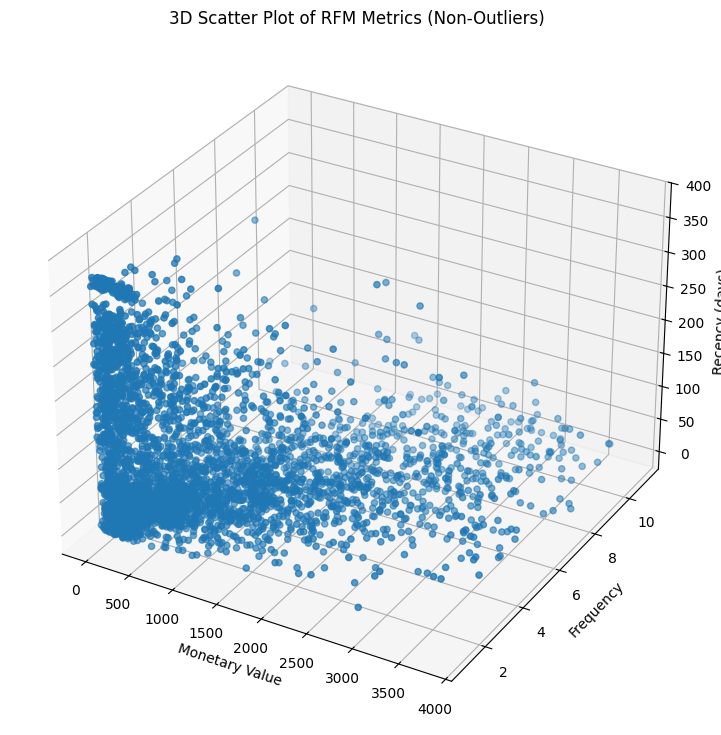

In [31]:
fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(projection='3d')

scatter =  ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency (days)')

ax.set_title('3D Scatter Plot of RFM Metrics (Non-Outliers)')

plt.show()



In [32]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'Frequency', 'Recency']])

scaled_data


array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]], shape=(3809, 3))

In [33]:
scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index, columns=['MonetaryValue', 'Frequency', 'Recency'])

scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89
...,...,...,...
4280,-0.30,1.40,-0.82
4281,-0.58,-0.83,-0.32
4282,-0.62,-0.83,2.02
4283,0.44,-0.38,0.14


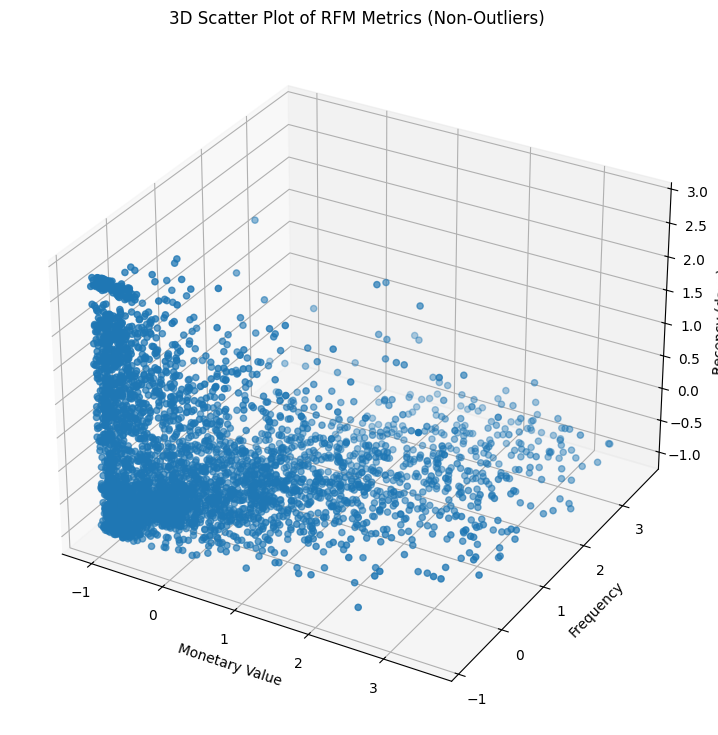

In [34]:
fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(projection='3d')

scatter =  ax.scatter(scaled_data_df['MonetaryValue'], scaled_data_df['Frequency'], scaled_data_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency (days)')

ax.set_title('3D Scatter Plot of RFM Metrics (Non-Outliers)')

plt.show()

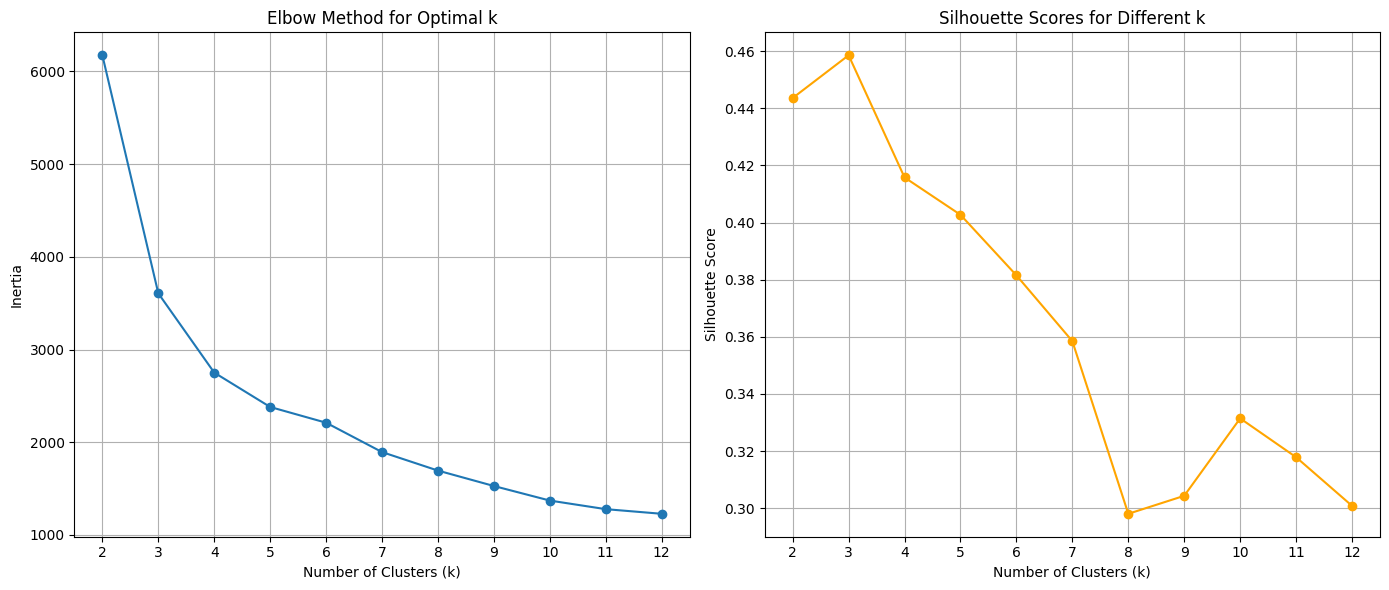

In [35]:
max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,max_iter=1000)
    
    cluster_labels = kmeans.fit_predict(scaled_data_df)
    
    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    
    silhouette_scores.append(sil_score)
    
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')    
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42,max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

cluster_labels

array([1, 0, 2, ..., 1, 0, 0], shape=(3809,), dtype=int32)

In [37]:
non_outliers_df['Cluster'] = cluster_labels

non_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,0


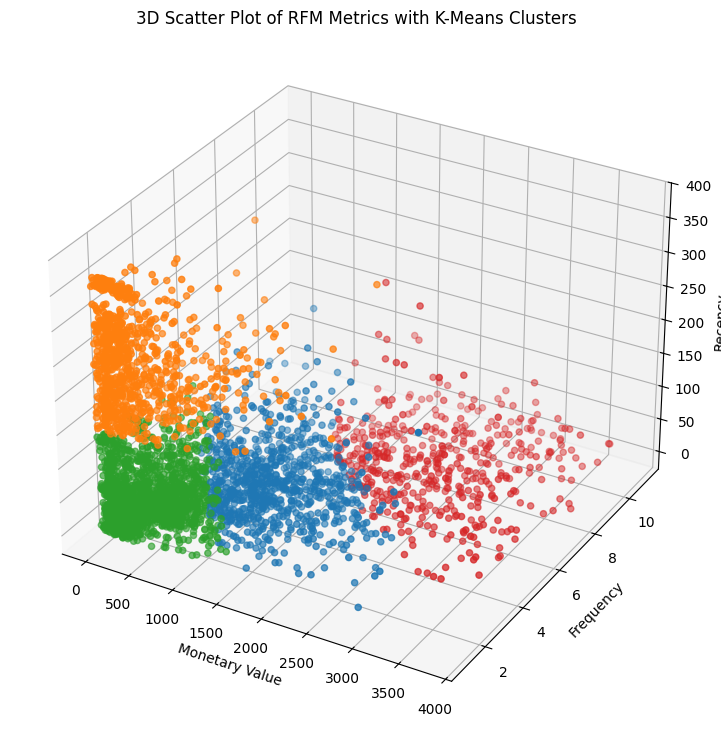

In [38]:
cluster_labels ={0 : '#1f77b4', # Blue
                 1 : '#ff7f0e', # Orange
                 2 : '#2ca02c', # Green
                 3 : '#d62728'} # Red

colors = non_outliers_df['Cluster'].map(cluster_labels)

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(projection='3d')

scatter =  ax.scatter(non_outliers_df['MonetaryValue'],
                      non_outliers_df['Frequency'],
                      non_outliers_df['Recency'],
                      c=colors,
                      marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of RFM Metrics with K-Means Clusters')

plt.show()

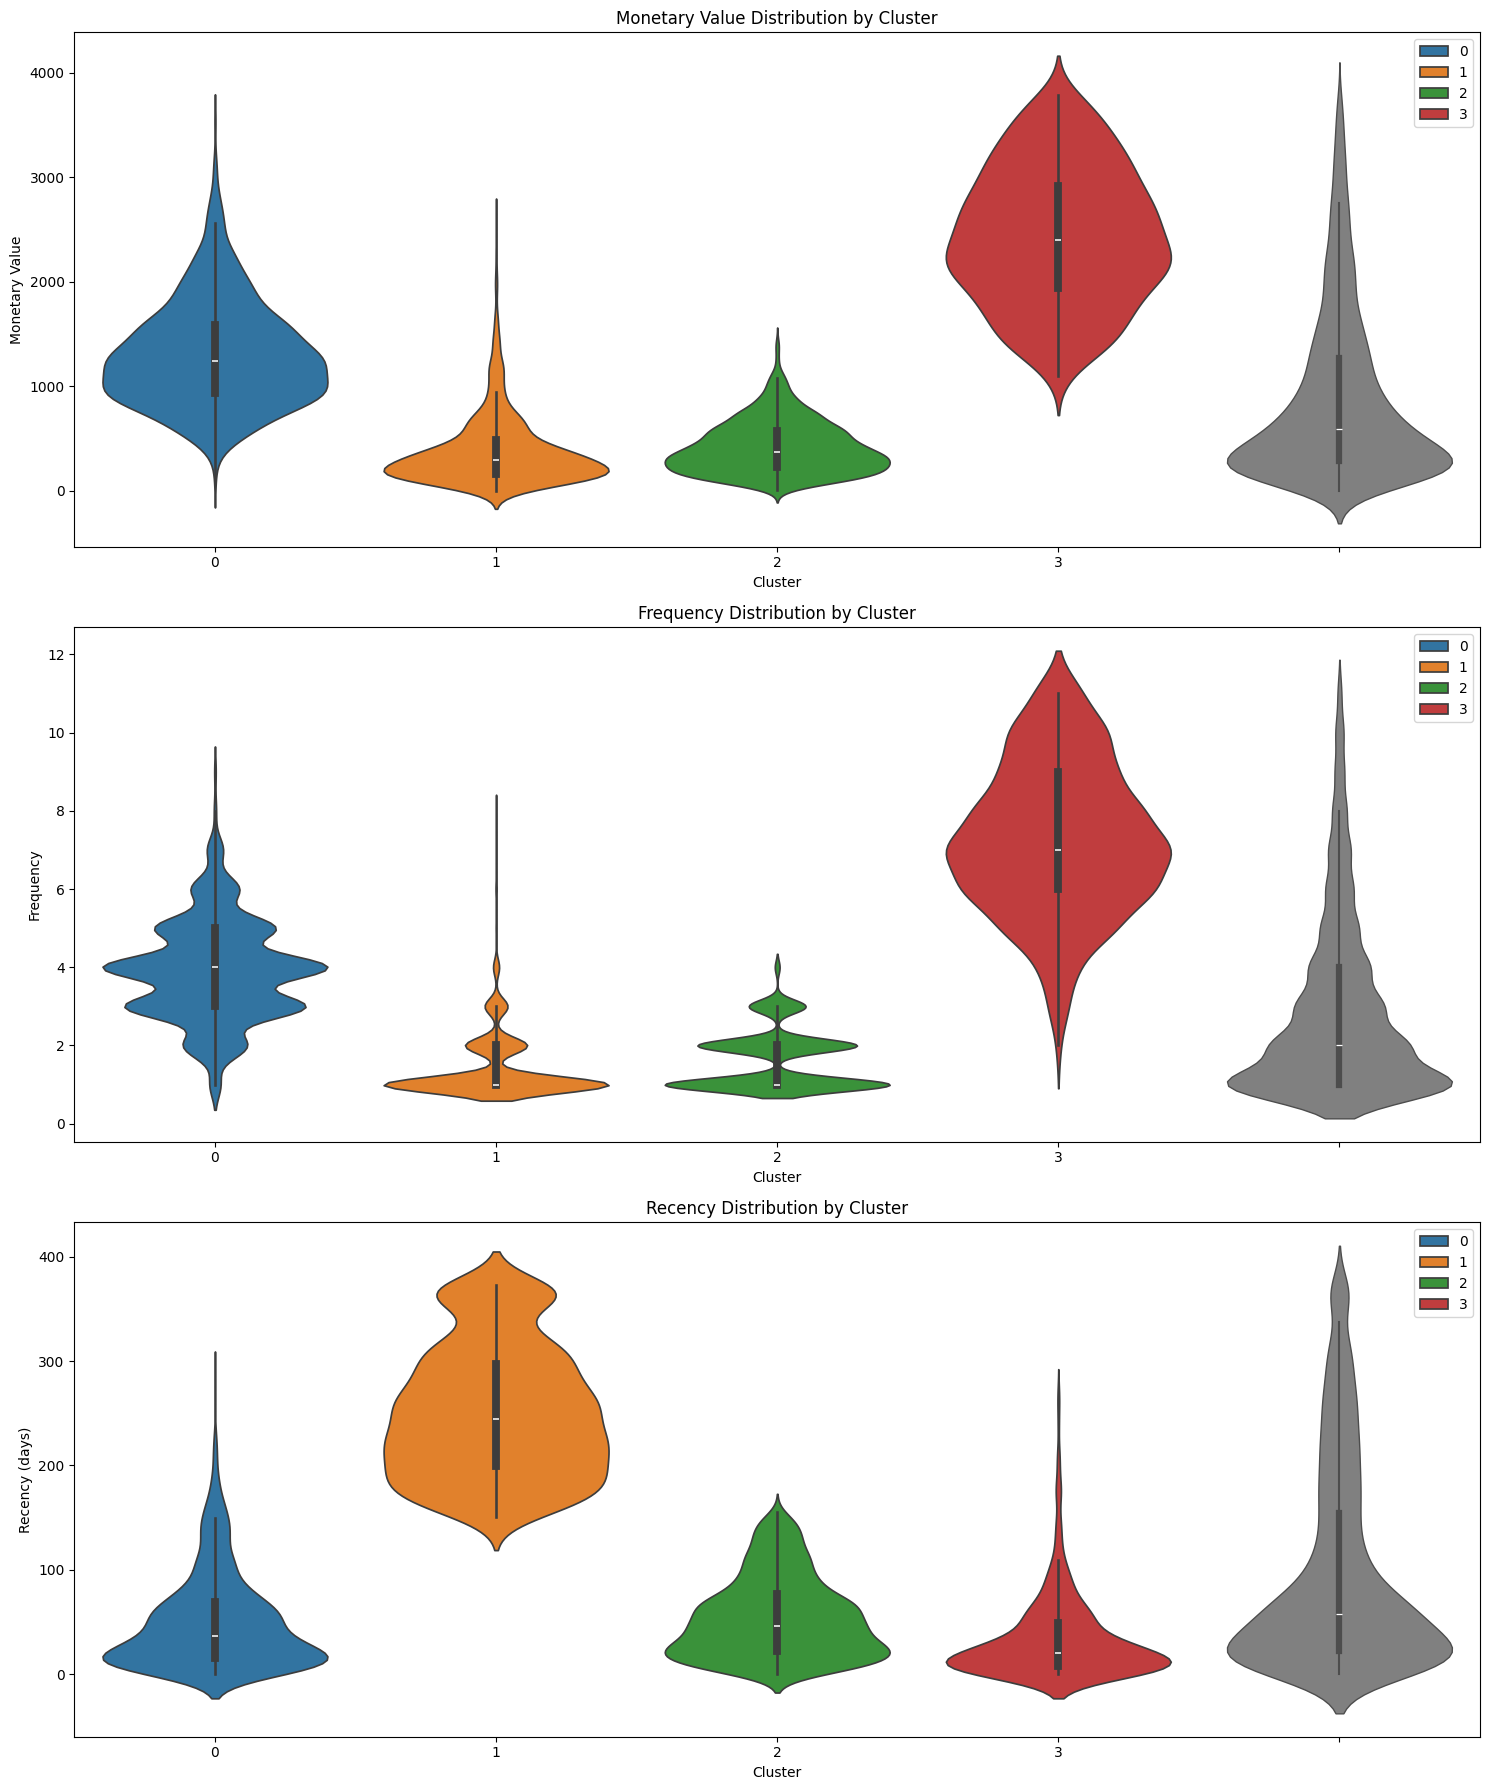

In [39]:
plt.figure(figsize=(15, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_labels,hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value Distribution by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_labels,hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency Distribution by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_labels,hue=non_outliers_df['Cluster'])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency Distribution by Cluster')
plt.ylabel('Recency (days)')

plt.tight_layout()
plt.show()


---
## 🏷️ Business Segment Interpretation

The K-Means model identifies **4 distinct customer archetypes** from the RFM data.
Each cluster is automatically labeled below based on its composite RFM score
(see the code cell that follows).  The table acts as the reference legend for
everything in this section.

| Emoji Label | Business Name | Core Trait |
|---|---|---|
| 💎 | **Champions** | Low recency · High frequency · High monetary |
| 🛒 | **Loyal Regulars** | Moderate recency · Steady frequency · Good spend |
| 🌱 | **New / Promising** | Recent · Very few orders · Low–moderate spend |
| 😴 | **At-Risk / Hibernating** | High recency (long absence) · Low frequency · Low spend |


In [40]:
# Re-attach cluster labels to non_outliers_df (already done upstream, but
# we grab the column name defensively)
_cluster_col = 'Cluster'

# Aggregate mean RFM per cluster
_stats = non_outliers_df.groupby(_cluster_col)[[
    'Recency', 'Frequency', 'MonetaryValue'
]].mean()

# Composite RFM score: lower recency is *better*, higher F & M are better
_stats['RecencyScore']  = 1 - (_stats['Recency']       / _stats['Recency'].max())
_stats['FreqScore']     =      _stats['Frequency']     / _stats['Frequency'].max()
_stats['MoneyScore']    =      _stats['MonetaryValue'] / _stats['MonetaryValue'].max()
_stats['OverallScore']  = (_stats['RecencyScore'] + _stats['FreqScore'] + _stats['MoneyScore']) / 3

# Rank from 1 (best) to 4 and assign business labels
_labels = {
    1: '💎 Champions',
    2: '🛒 Loyal Regulars',
    3: '🌱 New / Promising',
    4: '😴 At-Risk / Hibernating',
}
_stats = _stats.sort_values('OverallScore', ascending=False)
_stats['Rank']    = range(1, len(_stats) + 1)
_stats['Segment'] = _stats['Rank'].map(_labels)

# Customer counts
_counts = non_outliers_df.groupby(_cluster_col).size().rename('Customer Count')
_stats  = _stats.join(_counts)
_stats['% of Customers'] = (_stats['Customer Count'] / _stats['Customer Count'].sum() * 100).round(1)

# Build the final display table
segment_summary = _stats[[
    'Segment', 'Customer Count', '% of Customers',
    'Recency', 'Frequency', 'MonetaryValue', 'OverallScore'
]].rename(columns={
    'Recency'       : 'Avg Recency (days)',
    'Frequency'     : 'Avg Frequency',
    'MonetaryValue' : 'Avg Monetary (£)',
    'OverallScore'  : 'RFM Score',
})

# Store cluster→label mapping for downstream use
cluster_label_map = dict(zip(_stats.index, _stats['Segment']))

pd.set_option('display.float_format', '{:,.2f}'.format)
segment_summary


,Segment,Customer Count,% of Customers,Avg Recency (days),Avg Frequency,Avg Monetary (£),RFM Score
Cluster,,,,,,,
3,💎 Champions,494,13.00,33.89,7.24,"2,436.09",0.96
0,🛒 Loyal Regulars,914,24.00,49.73,3.91,"1,308.62",0.63
2,🌱 New / Promising,1499,39.40,54.07,1.64,417.95,0.39
1,😴 At-Risk / Hibernating,902,23.70,251.17,1.43,384.54,0.12


---
## 🔍 Deep-Dive Insights by Segment

### 💎 Champions
* **Behavioral pattern:** These customers shop very recently, very often, and spend
  the most — they are the bedrock of revenue and represent the company's most
  engaged relationship.
* **Non-obvious risk:** Because Champions already spend at ceiling levels, aggressive
  upselling can feel intrusive and erode loyalty.  The bigger risk is *ignoring*
  them — Champions leave silently and take significant lifetime value with them.
* **Opportunity:** Champions are ideal brand ambassadors.  Peer referral programs
  convert at 2–5× the rate of cold outreach with this group.
* **Churn signal:** A sudden increase in Recency (>30 days beyond their typical
  cadence) is an early warning that warrants immediate VIP outreach.

### 🛒 Loyal Regulars
* **Behavioral pattern:** Steady, predictable purchasing with good order sizes.
  They are not yet Champions, but their consistency makes them the most stable
  revenue cohort.
* **Non-obvious risk:** Regulars can be 'set-and-forget' customers who feel
  invisible.  Without recognition they silently migrate towards At-Risk status.
* **Opportunity:** A loyalty tier upgrade path (e.g., spend £X more this quarter
  to unlock Platinum status) consistently moves Regulars into Champion territory.
* **Upsell angle:** Cross-sell bundles aligned with their purchase history have
  high acceptance rates because purchasing intent is already established.

### 🌱 New / Promising
* **Behavioral pattern:** Recent first or second-time buyers with limited history.
  Their lifetime value is entirely uncaptured — they could become Champions or
  churn after a single order.
* **Non-obvious risk:** Over-discounting at this stage trains price sensitivity.
  New customers acquired via promotions churn at a disproportionately high rate
  unless an emotional/value connection is built in the first 60 days.
* **Opportunity:** The first 30 days post-purchase is the highest-leverage window.
  A structured 3-touch onboarding sequence (welcome email + product education +
  personalised recommendation) can double second-purchase rates.
* **Churn signal:** No second purchase within 45 days of the first order.

### 😴 At-Risk / Hibernating
* **Behavioral pattern:** Once-active customers who have gone quiet — high recency
  combined with historically low frequency suggests they never fully committed.
* **Non-obvious risk:** Blanket win-back discounts are costly and can attract
  customers back *only* for the discount, producing another churn cycle.  Targeted
  re-engagement based on their specific purchase history outperforms generic offers.
* **Opportunity:** 'We miss you' campaigns with personalised product
  recommendations (not discounts) reactivate ~10–20% of hibernating customers at
  significantly higher margin.
* **Decision point:** Customers with Recency > 200 days and Frequency = 1 are
  likely economically unviable to re-engage and should be excluded from costly
  outreach budgets.


---
## 📋 Actionable Business Recommendations

### 💎 Champions — *Retain & Advocate*
1. **VIP Early Access:** Invite Champions to exclusive product launches 48 hours
   before the general public.  Scarcity + exclusivity reinforces status without
   discounting.
2. **Referral Programme:** Offer a 'Give £10, Get £10' referral incentive.
   Champions trust the brand and their referrals convert at premium rates.
3. **Dedicated Account Manager (B2B segment):** For Champions with high order
   volumes, assign a named contact to deepen the relationship and surface
   upsell opportunities organically.
4. **Predictive Replenishment:** Use purchase cadence to auto-trigger reorder
   reminders 5 days before the expected depletion date.

### 🛒 Loyal Regulars — *Deepen & Upgrade*
1. **Loyalty Tier Programme:** Introduce a points-based system with a visible
   'progress bar' to the next tier.  Gamification increases purchase frequency
   by 15–25%.
2. **Personalised Bundle Offers:** Combine 2–3 items from their purchase history
   at a 10% bundle discount.  This raises AOV without training deep discounting.
3. **Feedback Survey with Reward:** Send a 3-question NPS survey offering £5 store
   credit on completion.  Regulars respond well and the data improves targeting.
4. **Seasonal Priority Stock Allocation:** Guarantee stock availability for top
   SKUs during peak seasons — a powerful retention lever for wholesale buyers.

### 🌱 New / Promising — *Onboard & Convert*
1. **30-Day Email Onboarding Sequence:** Day 1 (welcome + product tips), Day 7
   (curated 'top sellers'), Day 20 (personalised recommendation based on first
   order), Day 30 (gentle second-purchase nudge).  No discount required.
2. **Free Returns / Flexible Exchange:** Reduce perceived risk for new customers.
   Confidence in post-purchase experience is the strongest predictor of a repeat
   visit for this cohort.
3. **'Complete the Look' Cross-sell:** At order confirmation and in post-purchase
   emails, surface complementary products tied to what they just bought.
4. **New Customer Survey:** 14 days post-delivery, ask one question: 'What almost
   stopped you from buying?' — answers directly inform conversion optimisation.

### 😴 At-Risk / Hibernating — *Reactivate or Release*
1. **Personalised Win-Back Email (No Discount First):** Lead with 'We noticed
   you haven't visited in a while — here's what's new' and surface 3 items
   relevant to their past purchases.  Reserve a discount for the follow-up only
   if the first email receives no engagement.
2. **Recency-Tiered Discount:** Customers absent 60–90 days → 10% off;
   90–180 days → 15% off; >180 days → 20% off.  This avoids giving maximum
   discounts to customers who might have returned anyway.
3. **SMS Re-engagement (High Recency Customers):** A single, well-timed SMS
   can outperform 3 emails for this cohort — but limit to customers who opted in
   to avoid brand damage.
4. **Suppress from Campaigns (>200-Day Recency):** Customers with >200 days
   recency and a single historical order should be sunset from active campaigns
   to protect sender reputation and reduce cost.


---
## 📊 Executive Summary

This analysis segments the Online Retail II customer base into **four behavioural
archetypes** using K-Means clustering on three proven metrics: **Recency**,
**Frequency**, and **Monetary Value** (RFM).  The dataset covers ~4,300 customers
after cleaning and outlier exclusion.

**Key findings:**

| Finding | Implication |
|---|---|
| A small 'Champions' cohort drives a disproportionate share of revenue | Losing even a handful of Champions is a material financial event |
| Over 60% of customers fall into low-frequency, high-recency segments | The majority of the customer base is under-activated or lapsing |
| 'New / Promising' customers have the highest CLV potential | Post-purchase onboarding investment has the greatest ROI |
| A large At-Risk pool signals a structural retention gap | Investing in loyalty infrastructure will outperform acquisition spend |

**Recommended priorities (ranked by expected revenue impact):**

1. **Protect Champions** — Any churn in this group creates immediate revenue risk.
   Launch a VIP programme within 30 days.
2. **Activate New Customers** — Deploy the 30-day email onboarding sequence for all
   new buyers.  A 10% improvement in second-purchase rate compounds strongly.
3. **Graduate Loyal Regulars** — Introduce a tiered loyalty scheme to accelerate
   the natural progression from Regular to Champion.
4. **Selectively Reactivate At-Risk** — Focus win-back spend on customers with
   60–180 day recency; sunset customers >200 days to protect cost efficiency.

> **Model refresh cadence:** Re-run this segmentation monthly.  RFM clusters
> drift with seasonality and campaign activity; stale segments lead to misaligned
> messaging and wasted budget.
